# Final Model Selection & Pipeline Optimization

## Objective

The goal of this notebook is to optimize the complete NLP pipeline for fraudulent job posting detection.

The optimization includes:

- Text preprocessing
- TF-IDF configuration
- Model hyperparameters

The best pipeline will be exported for deployment in the production ML system.

In [1]:
!nvidia-smi

Mon Jul  6 13:41:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 30.5 MB/s eta 0:00:00


## Import Libraries


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import unicodedata

from bs4 import BeautifulSoup

import nltk


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import os
import time
import optuna

In [2]:
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("omw-1.4")

nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")


[nltk_data] Downloading package punkt to /home/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/user/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /home/user/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/user/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data

True

## Load Dataset

In [7]:
df = pd.read_csv("/content/drive/MyDrive/fake_job_postings.csv")

In [3]:
df = pd.read_csv("../data/fake_job_postings.csv")

## Create Text Feature

In [4]:
TEXT_COLUMNS = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

In [5]:
df[TEXT_COLUMNS] = df[TEXT_COLUMNS].fillna("")

In [6]:
df["text"] = df[TEXT_COLUMNS].agg(" ".join, axis=1)

In [7]:
X = df["text"]

y = df["fraudulent"]

## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Final Text Preprocessing Pipeline

In [9]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [10]:
def get_wordnet_pos(tag):

    if tag.startswith("J"):
        return wordnet.ADJ

    elif tag.startswith("V"):
        return wordnet.VERB

    elif tag.startswith("N"):
        return wordnet.NOUN

    elif tag.startswith("R"):
        return wordnet.ADV

    return wordnet.NOUN

In [11]:
def preprocess_text(text):
    """
    Cleans and preprocesses raw job posting text.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Lowercase
    text = text.lower()

    # Replace non-breaking spaces
    text = text.replace("\xa0", " ")

    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()

    # Normalize unicode characters
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8")

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|#url_\w+#", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Dataset-specific cleaning (MS Office artifacts)
    text = re.sub(r"\bmso\b", " ", text)
    text = re.sub(r"\b\d*pt\b", " ", text)
    text = re.sub(r"\b\d*in\b", " ", text)

    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", " ", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = nltk.word_tokenize(text)

    # POS tagging
    tagged_words = pos_tag(words)

    # Lemmatization + Stopword Removal
    cleaned_words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_words
        if word not in stop_words and len(word) > 1
    ]

    return " ".join(cleaned_words).strip()

In [15]:
X_train = X_train.apply(preprocess_text)

X_test = X_test.apply(preprocess_text)

In [16]:
print(X_train.iloc[0])

contact center representative tidewater finance co establish initial purpose purchasing service retail installment contract two division tidewater credit service provide indirect consumer retail finance option tidewater motor credit provide indirect consumer auto financing remain committed offer partnership dealer consumer create winwinwin situation success rely solely success dealer consumersfull time position include following benefit vacation hour month employment vacation hour year employment6 pay holiday well anniversary holiday benefitpaid personal sick leave day employmentfull benefit include health dental life disability insurancea 401k plan company match month employment base upon quarterly entry dateincentive bonus individual team goal certain positionsbilingual spanish eligible differential pay tidewater finance company locate virginia beach va full parttime position available contact center representative provide diverse lending solution dealer network promote employee inte

# Pipeline Optimization

## TF-IDF Parameter Optimization

Different TF-IDF configurations can significantly influence model performance.

The objective is to identify the feature extraction configuration that maximizes Recall, F1-score, and ROC-AUC while keeping the feature space computationally efficient.

In [17]:
tfidf_configs = [

    {
        "name": "Baseline",
        "max_features": 10000,
        "ngram_range": (1,2),
        "min_df": 2,
        "max_df": 0.95
    },

    {
        "name": "5000 Features",
        "max_features": 5000,
        "ngram_range": (1,2),
        "min_df": 2,
        "max_df": 0.95
    },

    {
        "name": "min_df=5",
        "max_features": 10000,
        "ngram_range": (1,2),
        "min_df": 5,
        "max_df": 0.95
    },

    {
        "name": "Unigrams",
        "max_features": 10000,
        "ngram_range": (1,1),
        "min_df": 2,
        "max_df": 0.95
    },

    {
        "name": "15000 Features",
        "max_features": 15000,
        "ngram_range": (1,2),
        "min_df": 2,
        "max_df": 0.95
    }
]

In [ ]:
tfidf_results = []

for config in tfidf_configs:

    print(f"Running: {config['name']}")

    vectorizer = TfidfVectorizer(
        max_features=config["max_features"],
        ngram_range=config["ngram_range"],
        min_df=config["min_df"],
        max_df=config["max_df"],
    )

    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = LinearSVC(
        class_weight="balanced",
        random_state=42,
    )

    model.fit(X_train_vec, y_train)

    y_pred = model.predict(X_test_vec)
    y_score = model.decision_function(X_test_vec)

    tfidf_results.append({
        "Experiment": config["name"],
        "Vocabulary Size": len(vectorizer.vocabulary_),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    })

Running: Baseline


Running: 5000 Features
Running: min_df=5
Running: Unigrams
Running: 15000 Features


In [ ]:
tfidf_results_df = pd.DataFrame(tfidf_results)

tfidf_results_df.sort_values(
    by=["F1 Score", "ROC-AUC"],
    ascending=False
)

,Experiment,Vocabulary Size,Precision,Recall,F1 Score,ROC-AUC
4,15000 Features,15000,0.889571,0.838150,0.863095,0.982290
0,Baseline,10000,0.850299,0.820809,0.835294,0.980400
2,min_df=5,10000,0.845238,0.820809,0.832845,0.980471
3,Unigrams,10000,0.849398,0.815029,0.831858,0.979656
1,5000 Features,5000,0.781421,0.826590,0.803371,0.976800


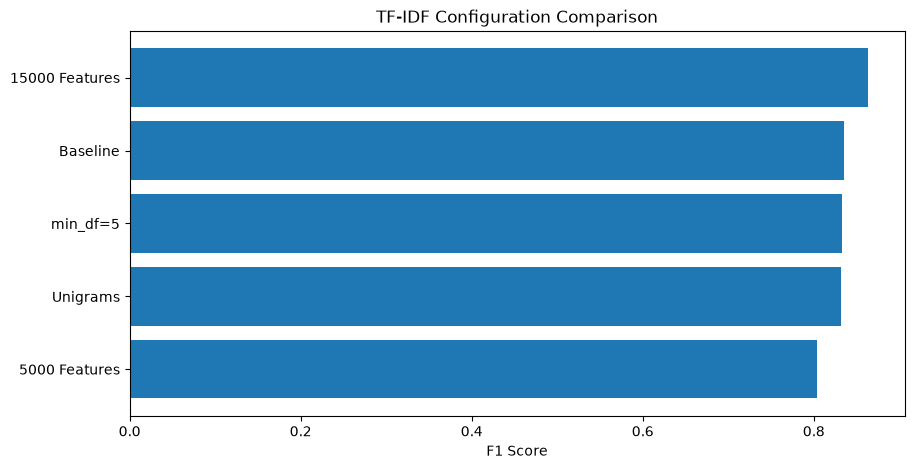

In [ ]:
plt.figure(figsize=(10, 5))

plot_df = tfidf_results_df.sort_values("F1 Score")

plt.barh(plot_df["Experiment"], plot_df["F1 Score"])

plt.xlabel("F1 Score")
plt.title("TF-IDF Configuration Comparison")

plt.show()

## Final TF-IDF Configuration

Selected Configuration

- max_features = 15000
- ngram = (1,2)
- min_df = 2
- max_df = 0.95

In [18]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train) 
X_test_tfidf = tfidf.transform(X_test) 

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    start = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Training Time (s)": train_time
    }

In [21]:
baseline_svm = LinearSVC(
    class_weight="balanced",
    random_state=42,
)

baseline_svm_metrics = evaluate_model(
    baseline_svm,
    X_train_tfidf, 
    X_test_tfidf, 
    y_train, 
    y_test
)

baseline_svm_metrics

{'Accuracy': 0.9871364653243848,
 'Precision': 0.8895705521472392,
 'Recall': 0.838150289017341,
 'F1 Score': 0.8630952380952381,
 'ROC-AUC': 0.9822903626348054,
 'Training Time (s)': 0.7017223834991455}

In [ ]:
baseline_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

baseline_xgb_metrics = evaluate_model(
    baseline_xgb,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

baseline_xgb_metrics

{'Accuracy': 0.9829418344519015,
 'Precision': 0.868421052631579,
 'Recall': 0.7630057803468208,
 'F1 Score': 0.8123076923076923,
 'ROC-AUC': np.float64(0.9752003927170687),
 'Training Time (s)': 68.71118307113647}

# Model Optimization

## Hyperparameter Optimization using Optuna

Traditional search techniques such as Grid Search and Random Search evaluate hyperparameter combinations without learning from previous trials.

This project uses **Optuna**, a modern hyperparameter optimization framework based on Bayesian Optimization (Tree-structured Parzen Estimator).

### Advantages

- Faster convergence
- Smarter search
- Efficient use of computational resources
- Industry adoption

In [31]:
def objective_svm(trial):

    C = trial.suggest_float(
        "C",
        1e-3,
        100,
        log=True
    )

    model = LinearSVC(
        C=C,
        class_weight="balanced",
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        scoring="f1",
        cv=3,
        n_jobs=-1
    ).mean()

    return score

In [32]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective_svm,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-07-06 15:38:54,284] A new study created in memory with name: no-name-b836d2b8-9d50-48a3-8cdd-a3df369c8ed0


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-07-06 15:38:57,674] Trial 0 finished with value: 0.7101067931220603 and parameters: {'C': 0.0745934328572655}. Best is trial 0 with value: 0.7101067931220603.
[I 2026-07-06 15:38:59,799] Trial 1 finished with value: 0.7854317902929807 and parameters: {'C': 56.69849511478853}. Best is trial 1 with value: 0.7854317902929807.
[I 2026-07-06 15:39:02,205] Trial 2 finished with value: 0.7907975368427346 and parameters: {'C': 4.5705630998014515}. Best is trial 2 with value: 0.7907975368427346.
[I 2026-07-06 15:39:03,545] Trial 3 finished with value: 0.7786731250728388 and parameters: {'C': 0.9846738873614566}. Best is trial 2 with value: 0.7907975368427346.
[I 2026-07-06 15:39:03,982] Trial 4 finished with value: 0.5637466084181533 and parameters: {'C': 0.006026889128682512}. Best is trial 2 with value: 0.7907975368427346.
[I 2026-07-06 15:39:04,428] Trial 5 finished with value: 0.5637466084181533 and parameters: {'C': 0.0060252157362038605}. Best is trial 2 with value: 0.790797536842

In [33]:
print("Best Trial")

print(study.best_trial.number)

print()

print("Best F1")

print(study.best_value)

print()

print("Best Parameters")

study.best_params

Best Trial
14

Best F1
0.7935316626107122

Best Parameters


{'C': 7.206647555113459}

In [34]:
best_svm = LinearSVC(
    **study.best_params,
    class_weight="balanced",
    random_state=42
)

best_svm.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=7.206647555113459, class_weight='balanced', random_state=42)

In [35]:
svm_metrics = evaluate_model(
    best_svm,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

svm_metrics

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'Accuracy': 0.9868568232662193,
 'Precision': 0.9436619718309859,
 'Recall': 0.7745664739884393,
 'F1 Score': 0.8507936507936508,
 'ROC-AUC': np.float64(0.9804286934853469),
 'Training Time (s)': 1.113945484161377}

In [23]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3,
            log=True
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma": trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "min_child_weight": trial.suggest_int(
            "min_child_weight",
            1,
            10
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10,
            log=True
        ),

        "random_state": 42,

        "eval_metric": "logloss",

        "n_jobs": -1,

        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum()
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1
    ).mean()

    return score

In [25]:
sampler = optuna.samplers.TPESampler(
    seed=42
)

study = optuna.create_study(
    direction="maximize",
    study_name="xgboost_optimization",
    sampler=sampler,
    pruner=MedianPruner()
)

study.optimize(
    objective_xgb,
    n_trials=10,
    show_progress_bar=True
)

NameError: name 'MedianPruner' is not defined

In [26]:
print("Best Trial")

print(study.best_trial.number)

print()

print("Best F1")

print(study.best_value)

print()

print("Best Parameters")

study.best_params

Best Trial
1

Best F1
0.7865768343507519

Best Parameters


{'n_estimators': 383,
 'max_depth': 3,
 'learning_rate': 0.2708160864249968,
 'subsample': 0.9329770563201687,
 'colsample_bytree': 0.6849356442713105,
 'gamma': 0.9091248360355031,
 'min_child_weight': 2,
 'reg_alpha': 5.472429642032198e-06,
 'reg_lambda': 0.00052821153945323}

In [27]:
best_xgb = XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

best_xgb.fit(
    X_train_tfidf,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6849356442713105, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.9091248360355031, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2708160864249968,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=383, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
xgb_metrics = evaluate_model(
    best_xgb,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

xgb_metrics

{'Accuracy': 0.985178970917226,
 'Precision': 0.8658536585365854,
 'Recall': 0.8208092485549133,
 'F1 Score': 0.8427299703264095,
 'ROC-AUC': np.float64(0.9801654099833705),
 'Training Time (s)': 66.0414731502533}

## Final Model Comparison

In [39]:
final_results = pd.DataFrame([
    {
        "Model": "Linear SVM (Baseline)",
        **baseline_svm_metrics
    },
    {
        "Model": "XGBoost (Baseline)",
        **baseline_xgb_metrics
    },
    {
        "Model": "Linear SVM (Optuna)",
        **svm_metrics
    },
    {
        "Model": "XGBoost (Optuna)",
        **xgb_metrics
    }
])

final_results.sort_values(
    by=["F1 Score", "ROC-AUC"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
0,Linear SVM (Baseline),0.987136,0.889571,0.838150,0.863095,0.982290,0.814263
2,Linear SVM (Optuna),0.986857,0.943662,0.774566,0.850794,0.980429,1.113945
3,XGBoost (Optuna),0.985179,0.865854,0.820809,0.842730,0.980165,66.041473
1,XGBoost (Baseline),0.982942,0.868421,0.763006,0.812308,0.975200,68.711183


# Final Model Selection

Based on the baseline experiments in Notebook 2, Linear SVM and XGBoost were selected for further optimization.

The preprocessing pipeline and TF-IDF configuration were fixed before performing hyperparameter optimization with Optuna.

## Results

- Optuna improved the performance of XGBoost.
- Optuna increased the Precision of Linear SVM but reduced its Recall and overall F1-score.
- The baseline Linear SVM consistently achieved the highest F1-score and ROC-AUC while maintaining the fastest training time.

## Final Production Model

**Linear SVM (Baseline)** was selected as the production model.

### Reasons

- Highest F1-score.
- Highest ROC-AUC.
- Strong balance between Precision and Recall.
- Excellent compatibility with sparse TF-IDF features.
- Fast training and inference.
- Simpler deployment and maintenance compared to XGBoost.

# Final Evaluation

## Classification Report

In [22]:
from sklearn.metrics import classification_report

y_pred = baseline_svm.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.89      0.84      0.86       173

    accuracy                           0.99      3576
   macro avg       0.94      0.92      0.93      3576
weighted avg       0.99      0.99      0.99      3576



## Confusion Matrix

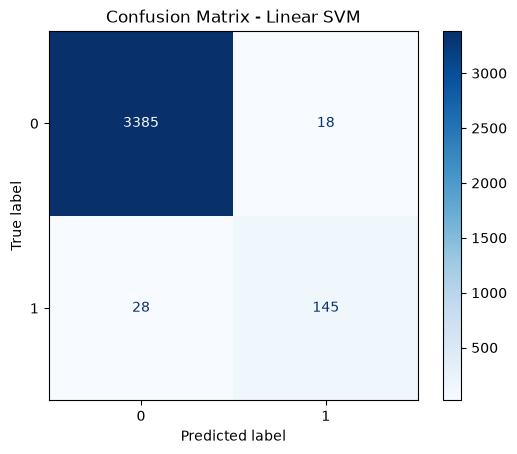

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    baseline_svm,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Linear SVM")

plt.show()

## ROC Curve

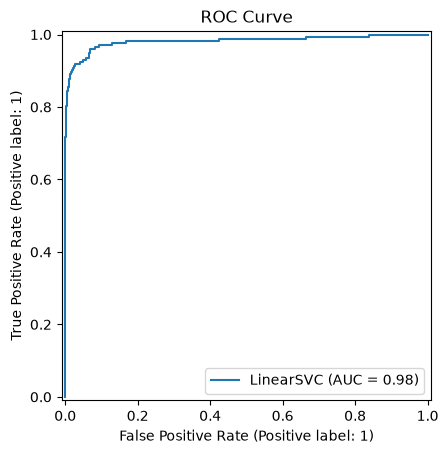

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    baseline_svm,
    X_test_tfidf,
    y_test
)

plt.title("ROC Curve")

plt.show()

## Precision-Recall Curve

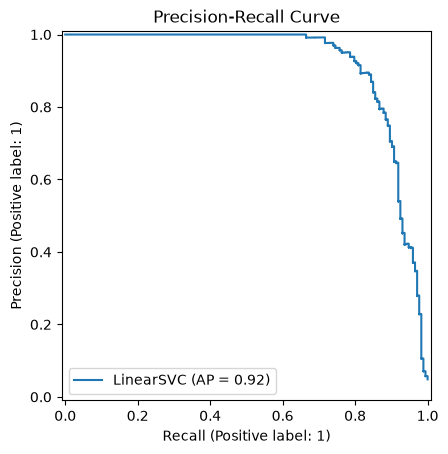

In [25]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    baseline_svm,
    X_test_tfidf,
    y_test
)

plt.title("Precision-Recall Curve")

plt.show()

## Saving Final Artifacts

In [30]:
import joblib

ARTIFACTS_DIR = os.path.join("..", "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(baseline_svm, "../artifacts/model.pkl")
joblib.dump(tfidf, "../artifacts/tfidf.pkl")

['../artifacts/tfidf.pkl']

# Engineering Decisions

## Input Features

The deployed model uses only textual information from job postings.

Merged Columns

- title
- company_profile
- description
- requirements
- benefits

---

## Text Preprocessing

The following preprocessing pipeline was selected after experimentation:

- Lowercasing
- HTML removal
- Unicode normalization
- URL removal
- Email removal
- MS Office artifact removal
- Number removal
- Punctuation removal
- Tokenization
- POS-aware lemmatization
- Stopword removal

---

## Feature Engineering

TF-IDF

- max_features = 15000
- ngram_range = (1,2)
- min_df = 2
- max_df = 0.95

---

## Model Selection

Two candidate models were shortlisted from the baseline experiments:

- Linear SVM
- XGBoost

Both models were optimized using Optuna.

The baseline Linear SVM achieved the highest F1-score and ROC-AUC while maintaining significantly lower computational cost than XGBoost.

Therefore, the baseline Linear SVM was selected as the final production model.

---

## Deployment Artifacts

The following artifacts will be exported for the production ML pipeline:

- model.pkl
- tfidf.pkl

# Conclusion

This notebook optimized the complete NLP pipeline for fraudulent job posting detection.

The experimentation included:

- Text preprocessing optimization
- Stopword removal analysis
- TF-IDF parameter optimization
- Hyperparameter optimization using Optuna
- Comparative evaluation of candidate models

After evaluating both predictive performance and computational efficiency, the baseline Linear SVM was selected as the final production model.

The selected preprocessing pipeline, TF-IDF vectorizer, and trained model will be integrated into the production-ready ML system developed in the subsequent implementation phase.